In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from vizman import viz
import os
import re 

import pickle

from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs

In [2]:
# Generate output folder
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis")
output_folder.mkdir(exist_ok=True)

# Load data 
with open(output_folder / "all_datasets_filtered.pkl", "rb") as f:
    dict_with_all_datasets = pickle.load(f)
    
# Folder now changed for saving 
output_folder = output_folder / "pca_results"
output_folder.mkdir(exist_ok=True)


In [3]:
# # Get minima locations: GNM dataset

# df_indiv_distances = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/05_mst_animal_0_compared_with_hcp_schaefer_100/summary_indiv_delta_con_for_exp_05_mst_animal_0_compared_with_hcp_schaefer_100.csv") 
# # For each column, get the row index of the minimum value. FIRST OCCURANCE!! 
# minima_indices = df_indiv_distances.drop(columns=["eta", "gamma"]).idxmin()

# # Save eta, gamma, network_index, id, and filename of the minima in a new dataframe
# df_minima = df_indiv_distances.loc[minima_indices].reset_index(drop=True)
# print(df_indiv_distances) 

In [4]:
print(dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"])

            eta     gamma    energy  avg_communicability  avg_edge_distance  \
0      1.204082  0.304082  0.320000             0.011247          76.077667   
1     -4.857143  0.663265  0.880000             0.014904          63.799976   
2     -5.979592  0.124490  0.940000             0.015729          70.102951   
3      0.530612  0.146939  0.670000             0.013722          69.063416   
4     -3.959184  0.932653  0.438384             0.012760          45.163860   
...         ...       ...       ...                  ...                ...   
24995 -3.285714 -0.032653  0.750000             0.014865          41.555737   
24996 -6.428571  0.887755  0.940000             0.015477          69.142136   
24997 -1.265306  0.685714  0.560000             0.012226          37.178089   
24998 -2.163265  0.842857  0.563636             0.011641          35.095871   
24999  0.755102 -0.055102  0.970000             0.015774          74.573944   

        wiring_cost  char_path_length  richclub_n_e

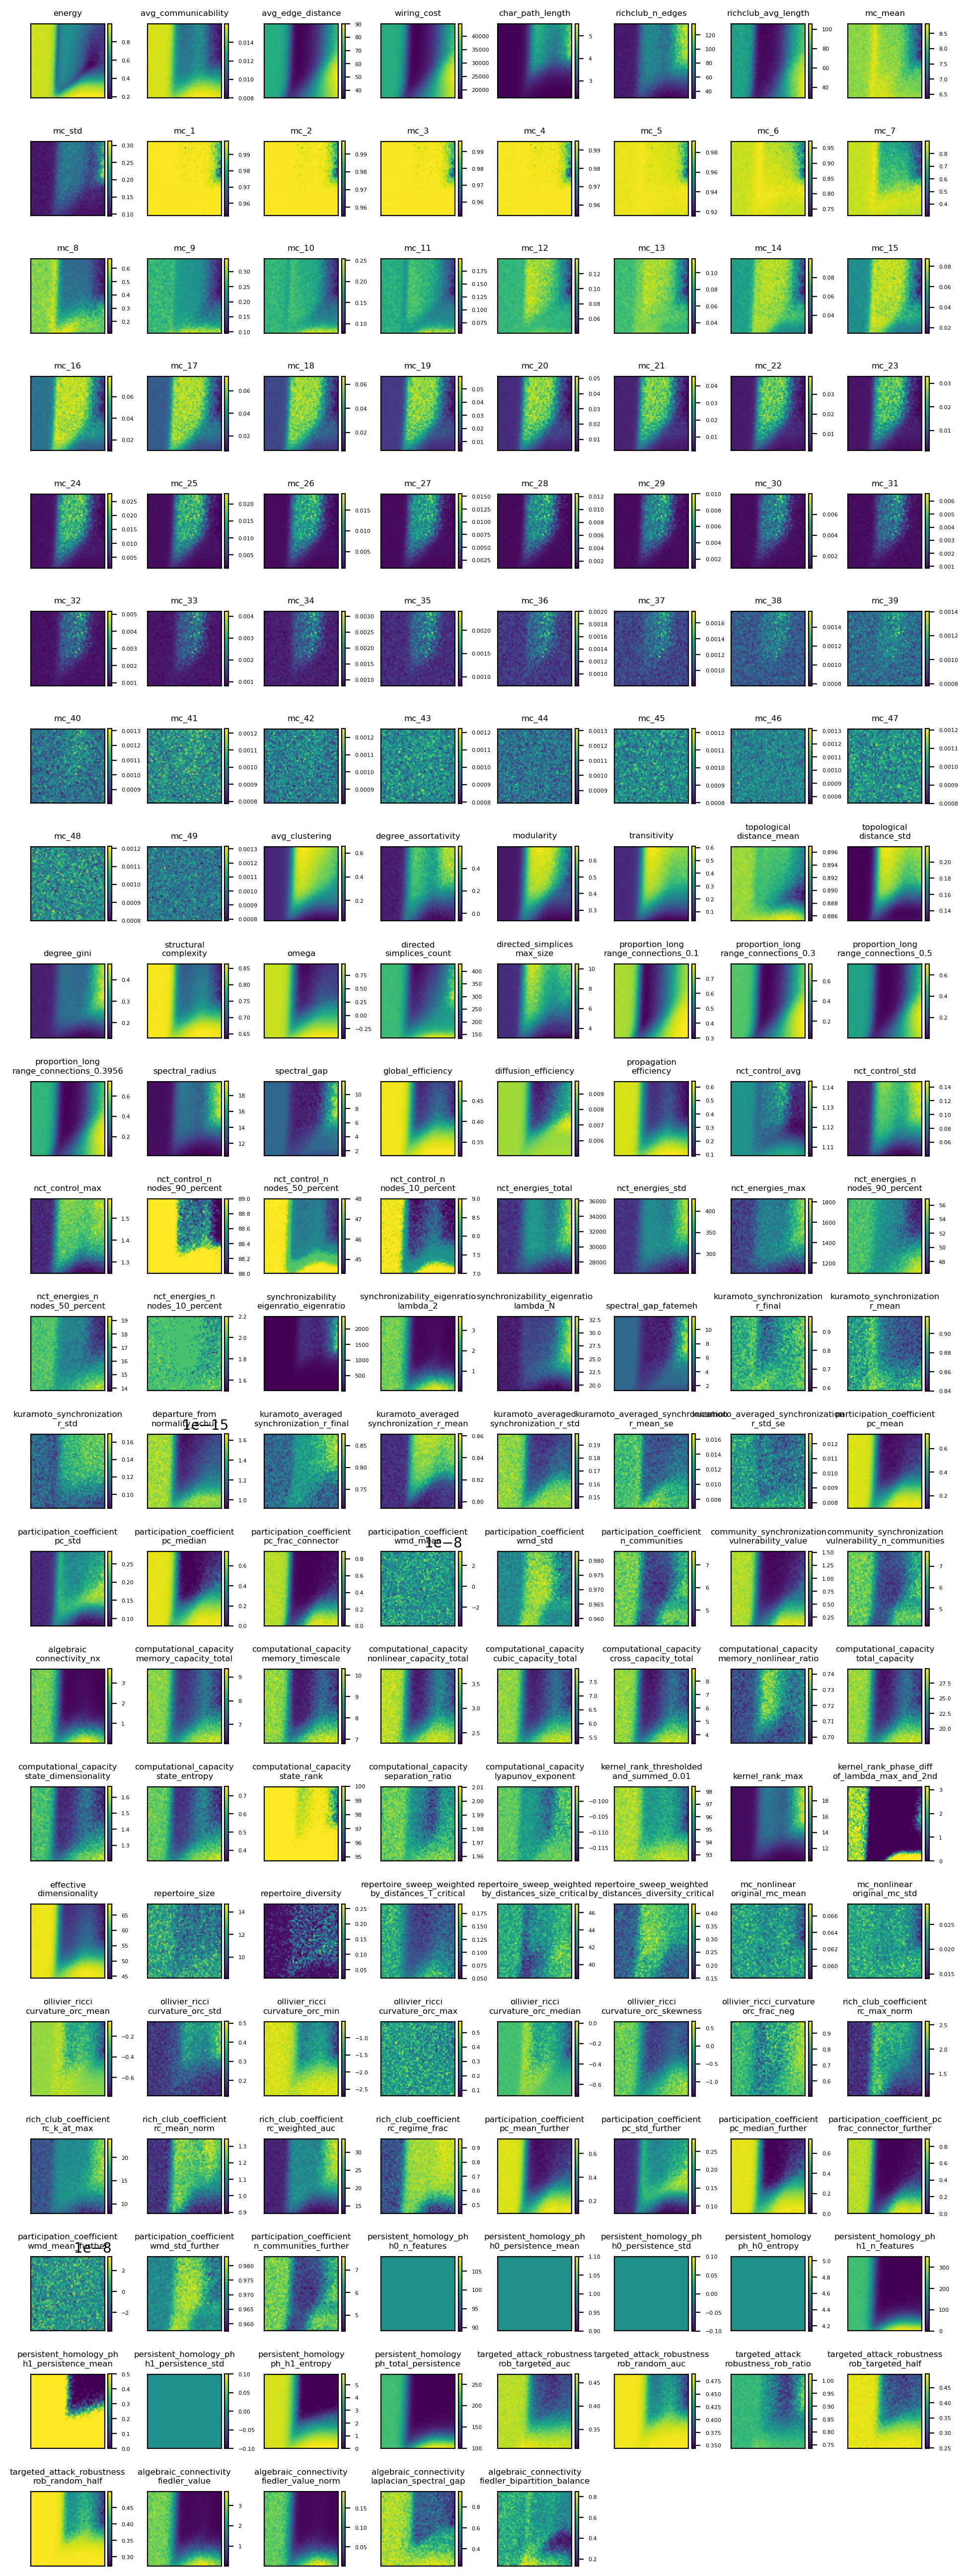

In [5]:
df_gnm_g = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].groupby(["eta", "gamma"]).mean().reset_index()

# EXCLUDE COLUMNS: 
constant_columns = ["avg_degree", "n_connected_components", "density", "density_bct", "kernel_rank_phase_of_lambda_max"]
df_gnm_g = df_gnm_g.drop(columns=[col for col in constant_columns if col in df_gnm_g.columns])

cols_of_interest = [col for col in df_gnm_g.columns if col not in ["eta", "gamma"]]
len(cols_of_interest)


n_cols = 8 
n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 3, n_rows * 3)), sharex=True, sharey=True, dpi=200)
for idx, col in enumerate(cols_of_interest):
    row = idx // n_cols
    col_idx = idx % n_cols
    ax = axes[row, col_idx]
    im = ax.imshow(df_gnm_g.pivot(index="gamma", columns="eta", values=col), aspect="equal", origin="lower", cmap="viridis")

    # if the title is too long (define this), then split it into two lines at the last underscore
    if len(col) > 20:  
        col = re.split(r'[,,_]+', col) # THIS IS OBV UGGLY: SEE ENERGY!! TODO Add comata again
        # col = col.split("_")
        len_col = len(col)
        col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
    ax.set_title(col, fontsize=6)
    
    ax.set_xticks([])
    ax.set_yticks([])
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=4) 
    
    # Add dots from the hcp dataset: TODO
    # so: minima eta and gamma combinations, in the color of dict_with_all_datasets["hcp_schaefer_100_dataset"].groupby(["eta", "gamma"]).mean().reset_index().apply(lambda row: ax.scatter(x=row["eta"], y=row["gamma"], color="red", s=10), axis=1)

# remove empty subplots
for idx in range(len(cols_of_interest), n_rows * n_cols):
    row = idx // n_cols
    col_idx = idx % n_cols
    fig.delaxes(axes[row, col_idx])
    
plt.tight_layout(pad=0.4)

## Now adding DeltaCon (or similar)

In [6]:
# df_test = df_indiv_distances.drop(columns=["filename"]).groupby(["eta", "gamma"]).mean().reset_index()

In [7]:

# # For each column in df_test that starts with "DeltaCon_subject", get the lowest value for "DeltaCon_subject" and the corresponding eta and gamma values. Plot these eta and gamma values as points on the same plot as above. 
# for col in df_test.columns:
#     if col.startswith("DeltaCon_subject"):
#         min_idx = df_test[col].idxmin()
#         plt.scatter(df_test.loc[min_idx, 'eta'], df_test.loc[min_idx, 'gamma'], color="red", s=10)
        
# # plt.xlim(-8,3)
# # plt.ylim(-0.1,1)

In [8]:
# df_merged["eta"]

In [9]:

# # Now, for the empirical datasets, get the individual energy minima and merge them. 
# dataset = "hcp_schaefer_100_dataset"
# experiment_name = emp_dataset_and_experiment_pairs[dataset]
# df_indiv_distances = pd.read_csv(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset}/{experiment_name}/summary_indiv_{distance_measure}_for_exp_{experiment_name}.csv")

# # For each column in df_test that starts with "DeltaCon_subject", get the lowest value for "DeltaCon_subject" and the corresponding eta and gamma values. Plot these eta and gamma values as points on the same plot as above. 
# for col in df_test.columns:
#     if col.startswith("DeltaCon_subject"):
#         min_idx = df_test[col].idxmin()
#         plt.scatter(df_test.loc[min_idx, 'eta'], df_test.loc[min_idx, 'gamma'], color="red", s=10)
        
# # plt.xlim(-8,3)
# # plt.ylim(-0.1,1)

In [10]:

# # Now, for the empirical datasets, get the individual energy minima and merge them. 
# dataset = "hcp_schaefer_100_dataset"
# experiment_name = emp_dataset_and_experiment_pairs[dataset]
# # df_indiv_distances = pd.read_csv(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset}/{experiment_name}/summary_indiv_{distance_measure}_for_exp_{experiment_name}.csv")

# for dataset in dict_with_all_datasets.keys():
#     if dataset == "hcp_schaefer_100_dataset_gnm":
#         continue

#     df_merged = dict_with_all_datasets[dataset]

#     if dataset == "hcp_schaefer_100_dataset" or dataset == "suarez_MaMI_dataset":
#         plt.scatter(df_merged["eta"], df_merged['gamma'], color=COLOR_SCHEME[dataset], label=LABEL_MAP[dataset],
#                 s=30)
    
#     else: # if dataset != "hcp_schaefer_100_dataset" and dataset != "suarez_MaMI_dataset": # TODO: add more datasets here, or make this more general.
#         plt.scatter(df_merged["eta"], df_merged['gamma'], color=COLOR_SCHEME[dataset], linewidths=1, edgecolors="black", s=75, label=LABEL_MAP[dataset]) 
    
# plt.xlim(-8,3)
# plt.ylim(-0.1,1)

# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # , fontsize=6)
# plt.title("Energy")

In [11]:

# # Now, for the empirical datasets, get the individual energy minima and merge them. 
# dataset = "hcp_schaefer_100_dataset"
# experiment_name = emp_dataset_and_experiment_pairs[dataset]
# df_indiv_distances = pd.read_csv(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset}/{experiment_name}/summary_indiv_{distance_measure}_for_exp_{experiment_name}.csv")

# for dataset in dict_with_all_datasets.keys():
#     if dataset == "hcp_schaefer_100_dataset_gnm":
#         continue

#     df_merged = dict_with_all_datasets[dataset]

#     plt.scatter(df_merged["eta"], df_merged['gamma'], color=COLOR_SCHEME[dataset],s=10)
    
# plt.xlim(-8,3)
# plt.ylim(-0.1,1)


In [12]:
# distance_measure = "delta_con" # "energy"
# # Get all minimal Energies (and the corresponding eta and gamma) for each subject, and merge them with the gnm data.
# dict_with_all_merged_datasets = {} 
# for dataset in dict_with_all_datasets.keys():
    
#     # Skip GNM
#     if dataset == "hcp_schaefer_100_dataset_gnm":
#         continue

#     # Now, for the empirical datasets, get the individual energy minima and merge them. 
#     experiment_name = emp_dataset_and_experiment_pairs[dataset]
#     df_indiv_distances = pd.read_csv(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset}/{experiment_name}/summary_indiv_{distance_measure}_for_exp_{experiment_name}.csv")

#     print(f"{dataset}: {len(dict_with_all_datasets[dataset].columns)} columns")
    
#     # Find minimum DeltaCon locations for each subject
#     df_min_locations = pd.DataFrame(columns=["delta_con", "eta_delta_con", "gamma_delta_con", "id_delta_con"])
#     maxcrit_cols = [col for col in df_indiv_distances.columns if col.startswith('DeltaCon_subject_')]
#     for maxcrit_col in maxcrit_cols:

#         min_idx = df_indiv_distances[maxcrit_col].idxmin()
#         plt.scatter(df_indiv_distances.loc[min_idx, 'eta'], df_indiv_distances.loc[min_idx, 'gamma'], color=COLOR_SCHEME[dataset], s=10)
        
    
# plt.xlim(-8,3)
# plt.ylim(-0.1,1)

# plt.title("DeltaCon")

In [14]:
# df_indiv_distances.drop(columns=["filename"]).groupby(["eta", "gamma"]).mean().reset_index()

hcp_schaefer_100_dataset: 172 columns
kaysons_generated_networks_diffusion: 174 columns
kaysons_generated_networks_propagation: 174 columns
kaysons_generated_networks_routing: 174 columns
kaysons_generated_networks_topology: 169 columns
suarez_MaMI_dataset: 174 columns
lexis_data_young: 170 columns
lexis_data_aging: 170 columns
lexis_data_developing: 170 columns


Text(0.5, 1.0, 'DeltaCon')

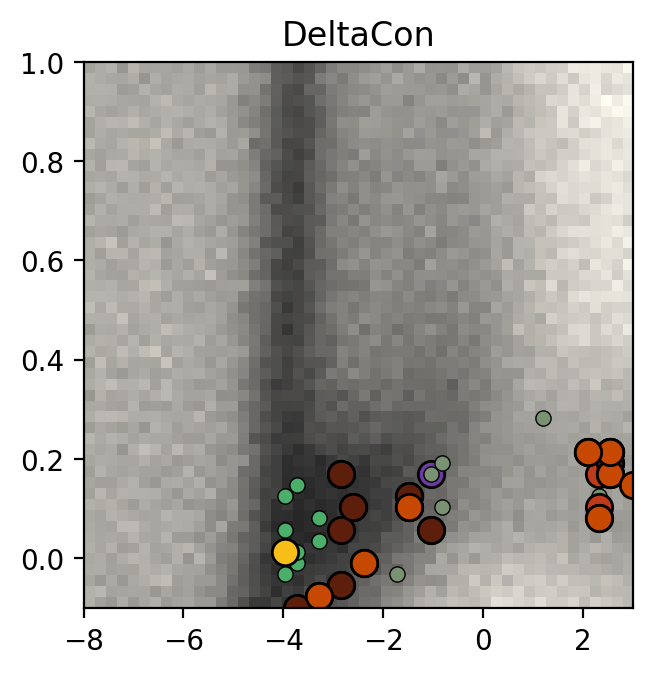

In [15]:
distance_measure = "delta_con" # "energy"
# Get all minimal Energies (and the corresponding eta and gamma) for each subject, and merge them with the gnm data.
dict_with_all_merged_datasets = {} 


plt.figure(figsize=viz.cm_to_inch((9,9)), dpi=200)
for dataset in dict_with_all_datasets.keys():
    
    # Skip GNM
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue
    
    # Now, for the empirical datasets, get the individual energy minima and merge them. 
    experiment_name = emp_dataset_and_experiment_pairs[dataset]
    df_indiv_distances = pd.read_csv(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset}/{experiment_name}/summary_indiv_{distance_measure}_for_exp_{experiment_name}.csv")
    # Average across locations
    df_indiv_distances = df_indiv_distances.drop(columns=["filename"]).groupby(["eta", "gamma"]).mean().reset_index()

    print(f"{dataset}: {len(dict_with_all_datasets[dataset].columns)} columns")

    # Create the heatmap
    if dataset == "hcp_schaefer_100_dataset": 
        # Average over all DeltaCon columns, such that we have one additional column DeltaCon_mean: df_indiv_distances
        df_indiv_distances["DeltaCon_mean"] = df_indiv_distances.filter(like="DeltaCon_subject_").mean(axis=1)
        pivot_data = df_indiv_distances.pivot(index="gamma", columns="eta", values="DeltaCon_mean")

        # Get the actual data ranges (STEP 1 TO COMBINE SCATTER AND IMSHOW)
        x_min, x_max = pivot_data.columns.min(), pivot_data.columns.max()
        y_min, y_max = pivot_data.index.min(), pivot_data.index.max()

        plt.imshow(pivot_data, 
                        extent=[x_min, x_max, y_min, y_max], # STEP 2 TO COMBINE SCATTER AND IMSHOW
                        aspect="auto", origin="lower", cmap=gray_cmap.reversed()) # "viridis")
        

    # Find minimum DeltaCon locations for each subject
    df_min_locations = pd.DataFrame(columns=["delta_con", "eta_delta_con", "gamma_delta_con", "id_delta_con"])
    maxcrit_cols = [col for col in df_indiv_distances.columns if col.startswith('DeltaCon_subject_')]
    
    saved_data = {}
    
    for maxcrit_col in maxcrit_cols:
        
        min_idx = df_indiv_distances[maxcrit_col].idxmin()

        saved_data.update({min_idx: {"eta": df_indiv_distances.loc[min_idx, 'eta'],
                                      "gamma": df_indiv_distances.loc[min_idx, 'gamma'],
                                      "id": df_indiv_distances.loc[min_idx, 'id']}})

    saved_df = pd.DataFrame.from_dict(saved_data, orient="index")
    
    if dataset == "hcp_schaefer_100_dataset" or dataset == "suarez_MaMI_dataset":
        plt.scatter(saved_df["eta"], saved_df['gamma'], color=COLOR_SCHEME[dataset], label=LABEL_MAP[dataset],edgecolors="black", # white", 
                    linewidths=0.5, s=30)
    
    else: # if dataset != "hcp_schaefer_100_dataset" and dataset != "suarez_MaMI_dataset": # TODO: add more datasets here, or make this more general.
        plt.scatter(saved_df["eta"], saved_df['gamma'], color=COLOR_SCHEME[dataset], linewidths=1, edgecolors="black", s=90, label=LABEL_MAP[dataset])


    
plt.xlim(-8,3)
plt.ylim(-0.1,1)

# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # , fontsize=6)
plt.title("DeltaCon")

In [16]:
distance_measure = "delta_con"  # energy
# Get all minimal Energies (and the corresponding eta and gamma) for each subject, and merge them with the gnm data.
dict_with_all_merged_datasets = {} 
for dataset in dict_with_all_datasets.keys():
    
    # Skip GNM
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    # Now, for the empirical datasets, get the individual energy minima and merge them. 
    experiment_name = emp_dataset_and_experiment_pairs[dataset]
    df_indiv_distances = pd.read_csv(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset}/{experiment_name}/summary_indiv_{distance_measure}_for_exp_{experiment_name}.csv")

    print(f"{dataset}: {len(dict_with_all_datasets[dataset].columns)} columns")
    
    # Find minimum DeltaCon locations for each subject
    df_min_locations = pd.DataFrame(columns=["delta_con", "eta_delta_con", "gamma_delta_con", "id_delta_con"])
    maxcrit_cols = [col for col in df_indiv_distances.columns if col.startswith('DeltaCon_subject_')]
    for maxcrit_col in maxcrit_cols:

        min_idx = df_indiv_distances[maxcrit_col].idxmin()
        df_min_locations = pd.concat([df_min_locations, pd.DataFrame({
                                            "delta_con": df_indiv_distances.loc[min_idx, maxcrit_col], # maxcrit_col, 
                                            "eta_delta_con": df_indiv_distances.loc[min_idx, 'eta'], 
                                            "gamma_delta_con": df_indiv_distances.loc[min_idx, 'gamma'], 
                                            "id_delta_con": df_indiv_distances.loc[min_idx, 'id'], 
                                            # "min_value": df_indiv_distances.loc[min_idx, maxcrit_col]
                                            },                   
                                            index=[0])], ignore_index=True)


    # Merge by index. If they already exist, then delete the existing columns.
    for col in df_min_locations.columns:
        if col in dict_with_all_datasets[dataset].columns:
            dict_with_all_datasets[dataset].drop(columns=[col], inplace=True)
    df_merged = pd.concat([df_min_locations, dict_with_all_datasets[dataset]], axis=1)
    dict_with_all_datasets[dataset] = df_merged

hcp_schaefer_100_dataset: 172 columns
kaysons_generated_networks_diffusion: 174 columns
kaysons_generated_networks_propagation: 174 columns
kaysons_generated_networks_routing: 174 columns
kaysons_generated_networks_topology: 169 columns


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_41696/4272036668.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_min_locations = pd.concat([df_min_locations, pd.DataFrame({
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_41696/4272036668.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_min_locations = pd.concat([df_min_locations, pd.DataFrame({
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_41696/4272036668.py:22: FutureWarning: The behavior of Da

suarez_MaMI_dataset: 174 columns


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_41696/4272036668.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_min_locations = pd.concat([df_min_locations, pd.DataFrame({


lexis_data_young: 170 columns


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_41696/4272036668.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_min_locations = pd.concat([df_min_locations, pd.DataFrame({


lexis_data_aging: 170 columns


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_41696/4272036668.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_min_locations = pd.concat([df_min_locations, pd.DataFrame({


lexis_data_developing: 170 columns


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_41696/4272036668.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_min_locations = pd.concat([df_min_locations, pd.DataFrame({


In [17]:
dict_with_all_datasets["hcp_schaefer_100_dataset"]

,delta_con,eta_delta_con,gamma_delta_con,id_delta_con,energy,eta,gamma,id,wiring_cost,avg_clustering,...,ollivier_ricci_curvature_orc_frac_neg,persistent_homology_ph_h0_n_features,persistent_homology_ph_h0_persistence_mean,persistent_homology_ph_h0_persistence_std,persistent_homology_ph_h0_entropy,persistent_homology_ph_h1_n_features,persistent_homology_ph_h1_persistence_mean,persistent_homology_ph_h1_persistence_std,persistent_homology_ph_h1_entropy,persistent_homology_ph_total_persistence
0,5.960299,-3.734694,0.146939,8,0.19,-0.142857,0.438776,9,4.344546,0.463335,...,0.367677,99.0,1.0,0.0,4.59512,7.0,0.5,0.0,1.945910,102.5
1,6.302177,-4.183673,0.057143,7,0.15,-3.734694,0.595918,6,4.279711,0.441039,...,0.484848,99.0,1.0,0.0,4.59512,21.0,0.5,0.0,3.044522,109.5
2,5.889659,-3.734694,0.146939,8,0.18,-3.734694,0.595918,6,4.145901,0.454073,...,0.460606,99.0,1.0,0.0,4.59512,13.0,0.5,0.0,2.564949,105.5
3,5.960299,-3.734694,0.146939,8,0.19,-3.734694,0.595918,6,4.014911,0.425323,...,0.488889,99.0,1.0,0.0,4.59512,17.0,0.5,0.0,2.833213,107.5
4,6.302177,-4.183673,0.057143,7,0.19,-0.816326,0.438776,8,4.159630,0.485091,...,0.464646,99.0,1.0,0.0,4.59512,10.0,0.5,0.0,2.302585,104.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,6.085623,-3.510204,0.034694,4,0.17,-0.591837,0.304082,0,4.349166,0.447762,...,0.496970,99.0,1.0,0.0,4.59512,17.0,0.5,0.0,2.833213,107.5
99,6.292601,-3.285714,0.146939,4,0.18,-3.734694,0.595918,6,4.071746,0.467366,...,0.466667,99.0,1.0,0.0,4.59512,11.0,0.5,0.0,2.397895,104.5
100,5.828483,-3.734694,0.146939,8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101,6.251517,-3.734694,0.146939,8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
df_gnm_g = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].groupby(["eta", "gamma"]).mean().reset_index()

# EXCLUDE COLUMNS: -> Already done previously. 
# constant_columns = ["avg_degree", "n_connected_components", "density", "density_bct", "kernel_rank_phase_of_lambda_max"]
df_gnm_g = df_gnm_g.drop(columns=[col for col in constant_columns if col in df_gnm_g.columns])

cols_of_interest = [col for col in df_gnm_g.columns if col not in ["eta", "gamma"]]
len(cols_of_interest)

173

,delta_con,eta_delta_con,gamma_delta_con,id_delta_con,energy,eta,gamma,id,wiring_cost,avg_clustering,...,ollivier_ricci_curvature_orc_frac_neg,persistent_homology_ph_h0_n_features,persistent_homology_ph_h0_persistence_mean,persistent_homology_ph_h0_persistence_std,persistent_homology_ph_h0_entropy,persistent_homology_ph_h1_n_features,persistent_homology_ph_h1_persistence_mean,persistent_homology_ph_h1_persistence_std,persistent_homology_ph_h1_entropy,persistent_homology_ph_total_persistence
0,5.960299,-3.734694,0.146939,8,0.19,-0.142857,0.438776,9,4.344546,0.463335,...,0.367677,99.0,1.0,0.0,4.59512,7.0,0.5,0.0,1.945910,102.5
1,6.302177,-4.183673,0.057143,7,0.15,-3.734694,0.595918,6,4.279711,0.441039,...,0.484848,99.0,1.0,0.0,4.59512,21.0,0.5,0.0,3.044522,109.5
2,5.889659,-3.734694,0.146939,8,0.18,-3.734694,0.595918,6,4.145901,0.454073,...,0.460606,99.0,1.0,0.0,4.59512,13.0,0.5,0.0,2.564949,105.5
3,5.960299,-3.734694,0.146939,8,0.19,-3.734694,0.595918,6,4.014911,0.425323,...,0.488889,99.0,1.0,0.0,4.59512,17.0,0.5,0.0,2.833213,107.5
4,6.302177,-4.183673,0.057143,7,0.19,-0.816326,0.438776,8,4.159630,0.485091,...,0.464646,99.0,1.0,0.0,4.59512,10.0,0.5,0.0,2.302585,104.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,6.085623,-3.510204,0.034694,4,0.17,-0.591837,0.304082,0,4.349166,0.447762,...,0.496970,99.0,1.0,0.0,4.59512,17.0,0.5,0.0,2.833213,107.5
99,6.292601,-3.285714,0.146939,4,0.18,-3.734694,0.595918,6,4.071746,0.467366,...,0.466667,99.0,1.0,0.0,4.59512,11.0,0.5,0.0,2.397895,104.5
100,5.828483,-3.734694,0.146939,8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101,6.251517,-3.734694,0.146939,8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


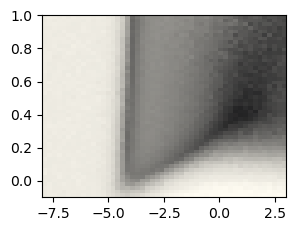

In [19]:
# Get the metric values at these minimum locations for coloring
# We'll use the same metric as shown in each subplot
# df_gnm_with_coords = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].copy()

# n_cols = 8
# n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
# fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 3, n_rows * 2.5)), sharex=True, sharey=True, dpi=200)
col = cols_of_interest[0] # energy


plt.figure(figsize=viz.cm_to_inch((8,6)))
# for idx, col in enumerate(cols_of_interest):

# Create the heatmap
pivot_data = df_gnm_g.pivot(index="gamma", columns="eta", values=col)

# Get the actual data ranges (STEP 1 TO COMBINE SCATTER AND IMSHOW)
x_min, x_max = pivot_data.columns.min(), pivot_data.columns.max()
y_min, y_max = pivot_data.index.min(), pivot_data.index.max()

plt.imshow(pivot_data, 
                extent=[x_min, x_max, y_min, y_max], # STEP 2 TO COMBINE SCATTER AND IMSHOW
                aspect="auto", origin="lower", cmap=gray_cmap.reversed()) # "viridis")

# Plot individual points
for dataset in dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]
    break 
df_merged 
    
    
#     if col in df_merged.columns:
#         plt.scatter(df_merged["eta_deltacon"], df_merged['gamma_deltacon'],
#             #    c=df_merged[col],
#                     c=COLOR_SCHEME[dataset],
#                     edgecolor="black",
#                     label=dataset,
#                     linewidth=0.25, s=20)

# # if the title is too long (define this), then split it into two lines at the last underscore
# if len(col) > 20:
#     col = re.split(r'[,,_]+', col)
#     len_col = len(col)
#     col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
# plt.title(col) #  fontsize=6)

# plt.xticks([])
# plt.yticks([])

# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
# cbar.ax.tick_params(labelsize=4) 
    
# plt.tight_layout(pad=0.4)

# plt.savefig(output_folder / "gnm_property_heatmaps_with_deltacon_minimums.pdf", dpi=200)

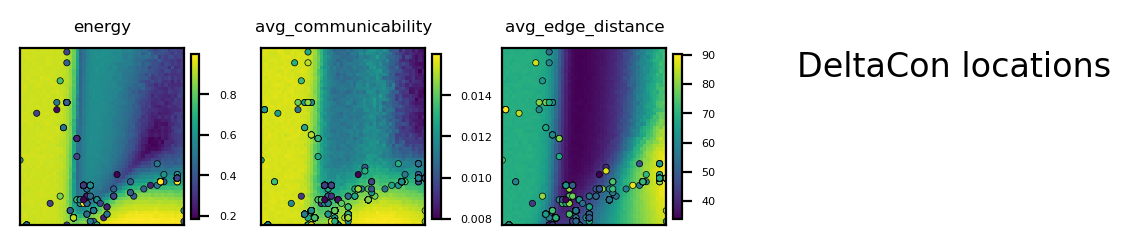

In [20]:
# Get the metric values at these minimum locations for coloring
# We'll use the same metric as shown in each subplot
# df_gnm_with_coords = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].copy()

n_cols = 8
n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 3, n_rows * 2.5)), sharex=True, sharey=True, dpi=200)

for idx, col in enumerate(cols_of_interest):
    row = idx // n_cols
    col_idx = idx % n_cols
    ax = axes[row, col_idx]
    
    # Create the heatmap
    pivot_data = df_gnm_g.pivot(index="gamma", columns="eta", values=col)

    # Get the actual data ranges (STEP 1 TO COMBINE SCATTER AND IMSHOW)
    x_min, x_max = pivot_data.columns.min(), pivot_data.columns.max()
    y_min, y_max = pivot_data.index.min(), pivot_data.index.max()

    im = ax.imshow(pivot_data, 
                   extent=[x_min, x_max, y_min, y_max], # STEP 2 TO COMBINE SCATTER AND IMSHOW
                   aspect="auto", origin="lower", cmap="viridis")
    
    # Plot individual points
    for dataset in dict_with_all_datasets.keys():

        # Skip the gnm dataset, as it will now have two eta and gamma columns. 
        if dataset == "hcp_schaefer_100_dataset_gnm":
            continue

        df_merged = dict_with_all_datasets[dataset]

        if col in df_merged.columns:
            ax.scatter(df_merged["eta_delta_con"], df_merged['gamma_delta_con'],
                       c=df_merged[col],
                       edgecolor="black",
                       linewidth=0.25, s=5)

    # if the title is too long (define this), then split it into two lines at the last underscore
    if len(col) > 20:
        col = re.split(r'[,,_]+', col)
        len_col = len(col)
        col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
    ax.set_title(col, fontsize=6)
    
    ax.set_xticks([])
    ax.set_yticks([])
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=4) 
    
    if idx >= 2: 
        break

# remove empty subplots
for idx in range(idx+1, n_rows * n_cols):
    row = idx // n_cols
    col_idx = idx % n_cols
    fig.delaxes(axes[row, col_idx])
    
plt.suptitle("DeltaCon locations")
    
plt.tight_layout(pad=0.4)

plt.savefig(output_folder / "gnm_property_heatmaps_with_deltacon_minimums.pdf", dpi=200)

In [21]:
# # save dict_with_all_merged_datasets: 
# with open(output_folder / "all_datasets_merged_with_minima_locations_deltacon.pkl", "wb") as f:
#     pickle.dump(dict_with_all_merged_datasets, f)

In [22]:
# dict_with_all_merged_datasets["suarez_MaMI_dataset"]

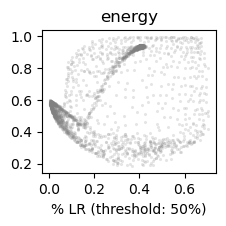

Save path:  /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results


In [23]:
for idx, col in enumerate(cols_of_interest):
    fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

    plt.scatter(df_gnm_g["proportion_long_range_connections_0.5"], df_gnm_g[col], 
               color="gray", linewidth=0, s=5, alpha=0.2) 

    if len(col) > 20:
        col_for_title = re.split(r'[,,_]+', col)
        len_col = len(col_for_title)
        col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

    if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
        col = "min_value"
        col_for_title = "Distance Measure"
    
    for dataset in dict_with_all_merged_datasets.keys():

        # Skip the gnm dataset, as it will now have two eta and gamma columns. 
        if dataset == "hcp_schaefer_100_dataset_gnm":
            continue

        df_merged = dict_with_all_merged_datasets[dataset]

        if col in df_merged.columns:
            plt.scatter(df_merged["proportion_long_range_connections_0.5"], # df_merged["eta"], df_merged['gamma'],
                       df_merged[col],
                    #    c = df_merged[col],
                       edgecolor="black",
                       color=COLOR_SCHEME[dataset],
                       linewidth=0.25, s=5)
    
    plt.xlabel("% LR (threshold: 50%)") # Percentage of\nLR connections (> 50 % length)")
    # plt.ylabel(col.replace("_", " ").capitalize())
    # if the title is too long (define this), then split it into two lines at the last underscore
    plt.title(col) # , fontsize=6)
    
    plt.tight_layout()
    plt.savefig(output_folder / f"fig_{idx}_{col}_scatter.png", dpi=200)
    if idx == 0:
        plt.show()
    else: 
        plt.close()

print("Save path: ", output_folder)

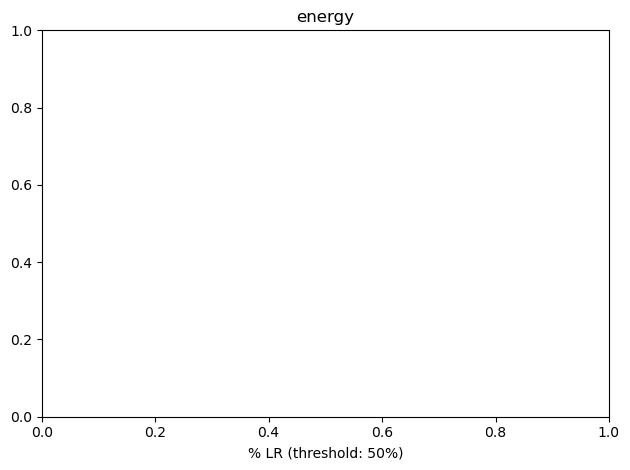

In [24]:
# for idx, col in enumerate(cols_of_interest):
#     fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

#     plt.scatter(df_gnm_g["proportion_long_range_connections_0.5"], df_gnm_g[col], 
#                color="gray", linewidth=0, s=5, alpha=0.2) 

#     if len(col) > 20:
#         col_for_title = re.split(r'[,,_]+', col)
#         len_col = len(col_for_title)
#         col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

#     if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
#         col = "min_value"
#         col_for_title = "Distance Measure"

col = "energy"

for dataset in dict_with_all_merged_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_merged_datasets[dataset]

    if col in df_merged.columns:
        plt.scatter(df_merged["proportion_long_range_connections_0.5"], # df_merged["eta"], df_merged['gamma'],
                    df_merged[col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    linewidth=0.25, s=5)

plt.xlabel("% LR (threshold: 50%)") # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.title(col) # , fontsize=6)

plt.tight_layout()
# plt.savefig(output_folder / f"fig_{idx}_{col}_scatter.png", dpi=200)
# if idx == 0:
#     plt.show()
# else: 
#     plt.close()

# print("Save path: ", output_folder)

In [25]:
df_gnm_g

,eta,gamma,energy,avg_communicability,avg_edge_distance,wiring_cost,char_path_length,richclub_n_edges,richclub_avg_length,mc_mean,...,persistent_homology_ph_total_persistence,targeted_attack_robustness_rob_targeted_auc,targeted_attack_robustness_rob_random_auc,targeted_attack_robustness_rob_ratio,targeted_attack_robustness_rob_targeted_half,targeted_attack_robustness_rob_random_half,algebraic_connectivity_fiedler_value,algebraic_connectivity_fiedler_value_norm,algebraic_connectivity_laplacian_spectral_gap,algebraic_connectivity_fiedler_bipartition_balance
0,-8.0,-0.100000,0.931,0.015520,68.912802,34111.837109,2.237475,35.3,74.740613,8.379198,...,221.65,0.44869,0.485927,0.923368,0.487,0.4983,2.666178,0.133791,0.812038,0.468
1,-8.0,-0.077551,0.934,0.015567,68.775390,34043.817578,2.238646,37.1,69.670481,8.407290,...,221.60,0.45505,0.486249,0.935839,0.491,0.4969,2.440664,0.123242,0.711938,0.440
2,-8.0,-0.055102,0.939,0.015572,68.838924,34075.267188,2.234909,39.2,72.679114,8.320874,...,221.55,0.45774,0.486455,0.940996,0.493,0.4981,3.068431,0.152928,0.871220,0.638
3,-8.0,-0.032653,0.933,0.015549,68.495776,33905.408984,2.235697,37.8,67.709734,8.379292,...,221.35,0.45647,0.486966,0.937376,0.493,0.4985,3.019175,0.153873,0.870720,0.638
4,-8.0,-0.010204,0.936,0.015602,69.017478,34163.651563,2.235172,35.9,69.975212,8.336929,...,222.90,0.45472,0.486586,0.934556,0.487,0.4976,2.993023,0.151654,0.880869,0.610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,3.0,0.910204,0.326,0.008264,71.699420,35491.212891,5.133980,128.4,83.668096,6.750237,...,99.00,0.35920,0.362585,0.992445,0.339,0.3015,0.019267,0.000615,0.330887,0.478
2496,3.0,0.932653,0.317,0.008387,73.086583,36177.858594,4.907172,126.9,84.562829,6.856519,...,99.00,0.35498,0.366310,0.977248,0.344,0.3065,0.022783,0.000728,0.341379,0.460
2497,3.0,0.955102,0.338,0.008264,73.510998,36387.944141,5.132020,126.7,84.072289,6.675188,...,99.00,0.35127,0.357857,0.987608,0.333,0.2983,0.021020,0.000681,0.392371,0.452
2498,3.0,0.977551,0.313,0.008357,73.208488,36238.201172,4.634364,123.8,85.426667,6.802856,...,99.00,0.34037,0.369171,0.929514,0.319,0.3097,0.033159,0.001035,0.414867,0.426


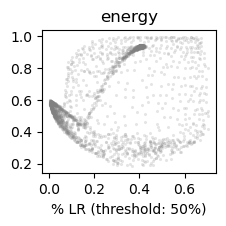

In [26]:

fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

plt.scatter(df_gnm_g["proportion_long_range_connections_0.5"], df_gnm_g[col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_merged_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_merged_datasets[dataset]

    if col in df_merged.columns:
        plt.scatter(df_merged["proportion_long_range_connections_0.5"], # df_merged["eta"], df_merged['gamma'],
                    df_merged[col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    linewidth=0.25, s=5)

plt.xlabel("% LR (threshold: 50%)") # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.title(col) # , fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_41696/4243622788.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)


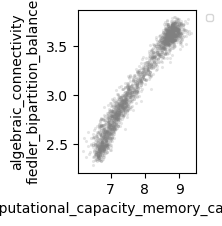

In [27]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "computational_capacity_memory_capacity_total"
y_col = "computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_merged_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_merged_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_41696/2713361139.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)


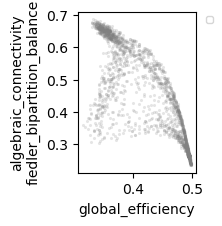

In [28]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "global_efficiency" # computational_capacity_memory_capacity_total"
y_col = "modularity" # computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_merged_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_merged_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_41696/4175181855.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)


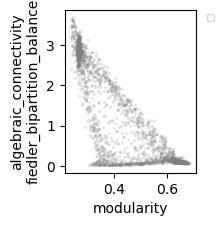

In [29]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "modularity" # computational_capacity_memory_capacity_total"
y_col = "algebraic_connectivity_fiedler_value" # computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_merged_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_merged_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_41696/524503894.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)


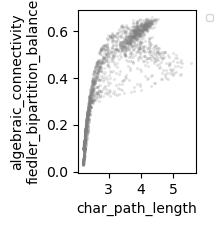

In [30]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "char_path_length" # modularity" # computational_capacity_memory_capacity_total"
y_col = "avg_clustering" # algebraic_connectivity_fiedler_value" # computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_merged_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_merged_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black", 
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout() # TODO: INCLUDE IN DOCS

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_41696/2386160329.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)


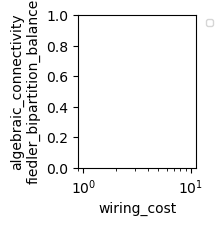

In [31]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "wiring_cost"
y_col = "computational_capacity_nonlinear_capacity_total"
# plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
#             color="gray", linewidth=0, s=5, alpha=0.2) 

# if len(col) > 20:
#     col_for_title = re.split(r'[,,_]+', y_col)
#     len_col = len(col_for_title)
#     col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

# if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
#     col = "min_value"
#     col_for_title = "Distance Measure"

for dataset in dict_with_all_merged_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_merged_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_41696/611676436.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)


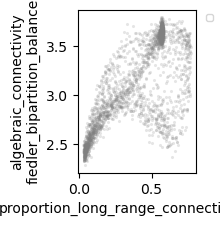

In [32]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "proportion_long_range_connections_0.3" # wiring_cost"
y_col = "computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_merged_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_merged_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_41696/4243622788.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)


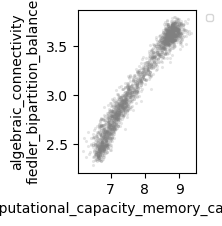

In [33]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "computational_capacity_memory_capacity_total"
y_col = "computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_merged_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_merged_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

In [34]:
dict_with_all_datasets["lexis_data_young"]

,delta_con,eta_delta_con,gamma_delta_con,id_delta_con,wiring_cost,proportion_long_range_connections_0.1,proportion_long_range_connections_0.3,proportion_long_range_connections_0.3956,proportion_long_range_connections_0.5,avg_clustering,...,algebraic_connectivity_fiedler_value,algebraic_connectivity_fiedler_value_norm,algebraic_connectivity_laplacian_spectral_gap,algebraic_connectivity_fiedler_bipartition_balance,avg_communicability,modularity,avg_edge_distance,char_path_length,richclub_n_edges,richclub_avg_length
0,7.693065,-3.061224,-0.010204,3,6.727157,0.775758,0.553535,0.446465,0.357576,0.500467,...,0.669283,0.025428,0.604443,0.68,0.011434,0.468889,67.951082,2.799798,74.0,68.967482
1,7.660328,-3.061224,-0.010204,3,6.666694,0.783838,0.537374,0.442424,0.357576,0.479110,...,0.675933,0.026689,0.608926,1.00,0.012082,0.457772,67.340343,2.757778,75.0,70.262989
2,7.656538,-3.061224,-0.010204,3,6.661734,0.773737,0.537374,0.430303,0.353535,0.465811,...,0.745189,0.027290,0.915130,0.72,0.011114,0.433668,67.290243,2.757374,86.0,66.529639
3,8.107149,-3.061224,-0.077551,7,6.789200,0.787879,0.547475,0.460606,0.375758,0.436832,...,0.765288,0.033576,0.618485,0.94,0.011618,0.399729,68.577776,2.784646,82.0,70.564366
4,7.965256,-3.061224,-0.010204,3,6.866596,0.805668,0.580972,0.477733,0.396761,0.465549,...,0.576315,0.022528,0.693240,0.66,0.010595,0.384458,69.499956,2.813535,98.0,71.470998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,8.172722,-3.061224,-0.077551,7,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1061,8.545176,-3.061224,-0.077551,7,6.750803,0.785425,0.552632,0.457490,0.356275,0.488509,...,0.384825,0.016685,0.483138,0.50,0.010750,0.428422,68.327966,2.841414,91.0,78.105249
1062,7.922080,-3.061224,-0.077551,7,6.847849,0.791919,0.547475,0.448485,0.369697,0.458682,...,0.668398,0.028148,0.952572,0.82,0.011822,0.411160,69.170188,2.679192,80.0,63.599547
1063,8.255574,-3.061224,-0.077551,7,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<>:14: SyntaxWarning: invalid escape sequence '\%'
<>:14: SyntaxWarning: invalid escape sequence '\%'
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_41696/4075626096.py:14: SyntaxWarning: invalid escape sequence '\%'
  x_label = f"$f_{{\\rm LR\\,(39.56\%)}}$" # "Proportion long-range\nconnections (≥ 0.40)"


hcp_schaefer_100_dataset_gnm 175
Skipped
hcp_schaefer_100_dataset 176
Skipped
kaysons_generated_networks_diffusion 178
kaysons_generated_networks_propagation 178
kaysons_generated_networks_routing 178
kaysons_generated_networks_topology 173
suarez_MaMI_dataset 178
lexis_data_young 174
lexis_data_aging 174
lexis_data_developing 174
hcp_schaefer_100_dataset_gnm 175
Skipped
hcp_schaefer_100_dataset 176
Skipped
kaysons_generated_networks_diffusion 178
kaysons_generated_networks_propagation 178
kaysons_generated_networks_routing 178
kaysons_generated_networks_topology 173
suarez_MaMI_dataset 178
lexis_data_young 174
lexis_data_aging 174
lexis_data_developing 174
hcp_schaefer_100_dataset_gnm 175
Skipped
hcp_schaefer_100_dataset 176
Skipped
kaysons_generated_networks_diffusion 178
kaysons_generated_networks_propagation 178
kaysons_generated_networks_routing 178
kaysons_generated_networks_topology 173
suarez_MaMI_dataset 178
lexis_data_young 174
lexis_data_aging 174
lexis_data_developing 174
h

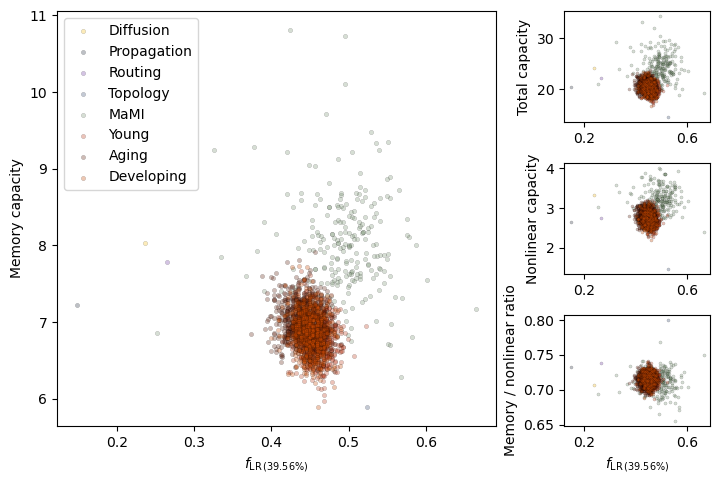

In [35]:
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/output") 
output_folder = output_folder / "trade_off_scatters"
output_folder.mkdir(exist_ok=True)

x_col = "proportion_long_range_connections_0.3956"

panels = {
    "A": ("computational_capacity_memory_capacity_total",    "Memory capacity"),
    "B": ("computational_capacity_total_capacity",           "Total capacity"),
    "C": ("computational_capacity_nonlinear_capacity_total", "Nonlinear capacity"),
    "D": ("computational_capacity_memory_nonlinear_ratio",   "Memory / nonlinear ratio"),
}

x_label = f"$f_{{\\rm LR\\,(39.56\%)}}$" # "Proportion long-range\nconnections (≥ 0.40)"

# ── mosaic layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplot_mosaic(
    """
    AAAB
    AAAC
    AAAD
    """,
    figsize=viz.cm_to_inch((18, 12)),
    layout="constrained",
    # share x across the small panels so zoom/pan stays in sync
    per_subplot_kw={
        "B": {"sharex": None},   # placeholder; real sharing done below
    },
)

# Share x-axis of B, C, D with each other (not with A — limits differ)
axes["C"].sharex(axes["B"])
axes["D"].sharex(axes["B"])

# ── shared plotting function ──────────────────────────────────────────────────
def plot_panel(ax, y_col, y_label, is_main=False):
    for dataset, df_merged in dict_with_all_datasets.items():
        print(dataset, len(df_merged.columns))
        if dataset == "hcp_schaefer_100_dataset_gnm" or dataset == "hcp_schaefer_100_dataset":
            print("Skipped")
            continue
        if x_col not in df_merged.columns or y_col not in df_merged.columns:
            print(f"Skipping {dataset} for panel {y_label} because required columns are missing.")
            continue

        ax.scatter(
            df_merged[x_col],
            df_merged[y_col],
            color=COLOR_SCHEME[dataset],
            edgecolor="black",
            linewidth=0.25,
            s=10 if is_main else 5,
            alpha=0.3,
            label=LABEL_MAP[dataset],
        )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if is_main:
        ax.legend()

# ── draw panels ───────────────────────────────────────────────────────────────
for panel_id, (y_col, y_label) in panels.items():
    ax = axes[panel_id]
    is_main = (panel_id == "A")
    plot_panel(ax, y_col, y_label, is_main=is_main)

    # ax.text(
    #     -0.15 if is_main else -0.35, 1.02,
    #     panel_id,
    #     transform=ax.transAxes,
    #     fontsize=8 if is_main else 6,
    #     fontweight="bold",
    #     va="bottom",
    # )

# ── align small-panel x-ticks to A's outermost ticks ─────────────────────────
fig.canvas.draw()                          # force matplotlib to compute auto-ticks

a_ticks = axes["A"].get_xticks()
# keep only ticks that fall within A's current view limits
a_xlim  = axes["A"].get_xlim()
a_ticks_visible = [t for t in a_ticks if a_xlim[0] <= t <= a_xlim[1]]

first_tick, last_tick = a_ticks_visible[0], a_ticks_visible[-1]

for panel_id in ("B", "C", "D"):
    ax = axes[panel_id]
    ax.set_xlim(a_xlim)                    # same data range as A
    ax.set_xticks([first_tick, last_tick])  # only the two boundary ticks
    # hide x-label on B and C to avoid clutter (only D gets the label)
    if panel_id != "D":
        ax.set_xlabel("")

plt.savefig(output_folder / "pareto_lr_connections.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [36]:
[i for i in df_merged.keys() if "repertoire" in i ]

['repertoire_sweep_weighted_by_distances_T_critical',
 'repertoire_sweep_weighted_by_distances_size_critical',
 'repertoire_sweep_weighted_by_distances_diversity_critical']

hcp_schaefer_100_dataset_gnm
Skipped
hcp_schaefer_100_dataset
Skipped
kaysons_generated_networks_diffusion
Skipped
kaysons_generated_networks_propagation
Skipped
kaysons_generated_networks_routing
Skipped
kaysons_generated_networks_topology
Skipped
suarez_MaMI_dataset
lexis_data_young
lexis_data_aging
lexis_data_developing


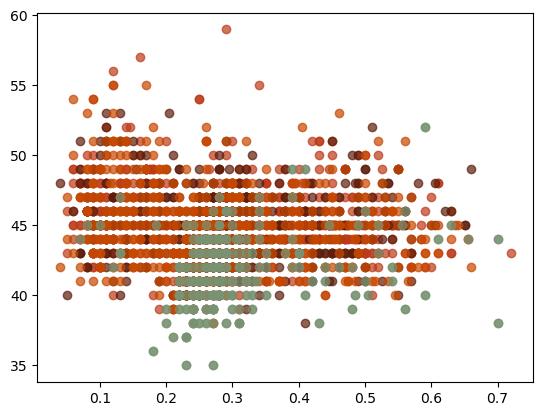

In [37]:
x_label = "repertoire_sweep_weighted_by_distances_diversity_critical" # proportion_long_range_connections_0.3956"
y_label = "repertoire_sweep_weighted_by_distances_size_critical" # repertoire_sweep_weighted_by_distances_diversity_critical"

# iterate through the datasets 
for dataset_name, df_merged in dict_with_all_datasets.items():
    print(dataset_name)
    # if both keys exist in df 
    if x_label in df_merged.columns and y_label in df_merged.columns and "hcp" not in dataset_name and "kayson" not in dataset_name:
        plt.scatter(df_merged[x_label], df_merged[y_label], 
                    c=COLOR_SCHEME[dataset_name], 
                    label=LABEL_MAP[dataset_name], 
                    alpha=0.7)
    else: 
        print("Skipped")
        
df_merged = dict_with_all_datasets["suarez_MaMI_dataset"]
plt.scatter(df_merged[x_label], df_merged[y_label], 
            c=COLOR_SCHEME["suarez_MaMI_dataset"], 
            label=LABEL_MAP["suarez_MaMI_dataset"], 
            alpha=0.7)

In [38]:
dict_with_all_datasets.keys()


dict_keys(['hcp_schaefer_100_dataset_gnm', 'hcp_schaefer_100_dataset', 'kaysons_generated_networks_diffusion', 'kaysons_generated_networks_propagation', 'kaysons_generated_networks_routing', 'kaysons_generated_networks_topology', 'suarez_MaMI_dataset', 'lexis_data_young', 'lexis_data_aging', 'lexis_data_developing'])

In [39]:
# get ages 
x_label = "repertoire_sweep_weighted_by_distances_diversity_critical" # proportion_long_range_connections_0.3956"
y_label = "repertoire_sweep_weighted_by_distances_size_critical" # repertoire_sweep_weighted_by_distances_diversity_critical"

dict_with_all_ages = {}

# iterate through the datasets 
for dataset_name, df_merged in dict_with_all_datasets.items():
    if "lexis" in dataset_name:
        ages = np.load(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/{dataset_name}/04_further_info/00_ages.npy")
        dict_with_all_ages[dataset_name] = ages
        print(dataset_name, df_merged.shape, len(ages))
        # plt.scatter(df_merged[x_label], df_merged[y_label], 
        #             c=dict_with_all_ages[dataset_name], # COLOR_SCHEME[dataset_name], 
        #             label=LABEL_MAP[dataset_name], 
        #             alpha=0.7)
        
# df_merged = dict_with_all_datasets["suarez_MaMI_dataset"]
# plt.scatter(df_merged[x_label], df_merged[y_label], 
#             c=COLOR_SCHEME["suarez_MaMI_dataset"], 
#             label=LABEL_MAP["suarez_MaMI_dataset"], 
#             alpha=0.7)



lexis_data_young (1065, 174) 1065
lexis_data_aging (718, 174) 718
lexis_data_developing (1270, 174) 635


In [40]:
np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/lexis_data_young/04_further_info/00_ages.npy")

array([20., 27., 27., ..., 29., 30., 25.], shape=(1065,))

# OLD


In [41]:

plt.figure(figsize=viz.cm_to_inch((12,12)))

for dataset_name in dict_with_all_datasets:
    print(dataset_name)
    df = dict_with_all_datasets[dataset_name]
    print(df["wiring_cost"].shape)
    if dataset_name == "hcp_schaefer_100_dataset_gnm": 
        plt.scatter(df["wiring_cost"], df["computational_capacity_nonlinear_capacity_total"], c=df["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"], cmap=gray_cmap, s=5, alpha=0.2, linewidths=0, label=dataset_name)
    else: 
        print(COLOR_SCHEME[dataset_name])
        plt.scatter(df["wiring_cost"], df["computational_capacity_nonlinear_capacity_total"], s=10, label=dataset_name, marker="o", color=COLOR_SCHEME[dataset_name], linewidths=0.25, edgecolors="black")


# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

hcp_schaefer_100_dataset_gnm
(25000,)


KeyError: 'MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)'

<Figure size 472.441x472.441 with 0 Axes>

In [ ]:
np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/lexis_data_aging/01_connectomes/00_individual_connectomes_bin.npy").shape

(718, 100, 100)

In [ ]:

plt.figure(figsize=viz.cm_to_inch((12,12)))

for dataset_name in dict_with_all_datasets:
    print(dataset_name)
    df = dict_with_all_datasets[dataset_name]
    print(df["wiring_cost"].shape)
    if dataset_name == "hcp_schaefer_100_dataset_gnm": 
        pass
        # plt.scatter(df["wiring_cost"], df["wiring_cost_dupa"], c=df["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"], cmap=gray_cmap, s=5, alpha=0.2, linewidths=0, label=dataset_name)
    else: 
        print(COLOR_SCHEME[dataset_name])
        plt.scatter(df["wiring_cost"], df["avg_communicability"], s=10, label=dataset_name, marker="o", color=COLOR_SCHEME[dataset_name], linewidths=0.25, edgecolors="black")


# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [ ]:

# --- Single scatter: wiring_cost vs computational capacity ---
fig, ax = plt.subplots(figsize=(10, 7))
for dataset_name, df in dict_with_all_datasets.items():
    if "wiring_cost" in df.columns and "computational_capacity_nonlinear_capacity_total" in df.columns:
        
        if dataset_name == "hcp_schaefer_100_dataset_gnm":
            ax.scatter(
                df["wiring_cost"],
                df["computational_capacity_nonlinear_capacity_total"],
                label=LABEL_MAP.get(dataset_name, dataset_name),
                color=COLOR_SCHEME.get(dataset_name, "gray"),
                # marker=MARKER_MAP.get(dataset_name, "o"),
                alpha=0.6,
                edgecolors="k",
                linewidths=0.3,
                s=30,
            )
        else:
            ax.scatter(
                df["wiring_cost"],
                df["computational_capacity_nonlinear_capacity_total"],
                label=LABEL_MAP.get(dataset_name, dataset_name),
                color=COLOR_SCHEME.get(dataset_name, "gray"),
                # marker=MARKER_MAP.get(dataset_name, "o"),
                alpha=0.6,
                edgecolors="k",
                linewidths=0.3,
                s=30,
            )
            
ax.set_xlabel("Wiring Cost", fontsize=12)
ax.set_ylabel("Computational Capacity (Nonlinear Total)", fontsize=12)
ax.set_title("Wiring Cost vs. Computational Capacity", fontsize=14)
ax.legend(fontsize=9, framealpha=0.9)
sns.despine()
plt.tight_layout()

plt.savefig(output_folder / "scatter_wiring_vs_comp_capacity.png", dpi=200)
print(output_folder / "scatter_wiring_vs_comp_capacity.png")
plt.show()


In [ ]:
shared_numeric_cols = None
for df in dict_with_all_datasets.values():
    numeric_cols = set(df.select_dtypes(include=[np.number]).columns)
    if shared_numeric_cols is None:
        shared_numeric_cols = numeric_cols
    else:
        shared_numeric_cols = shared_numeric_cols & numeric_cols

for col in shared_numeric_cols: 
    print(col)

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_11585/1341220627.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


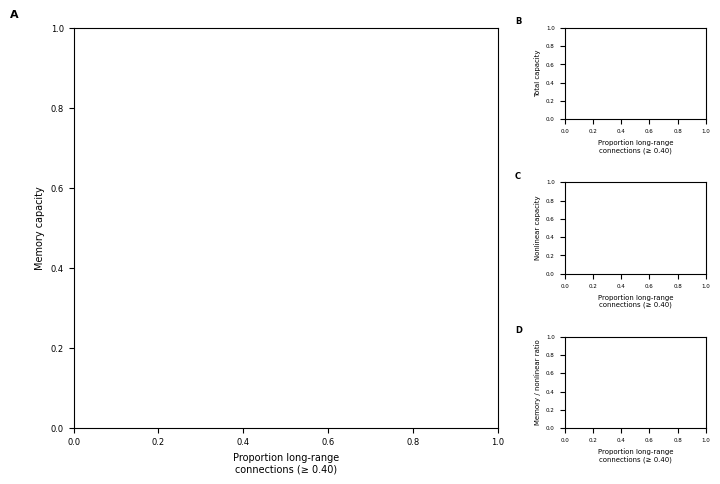